In [2]:
import numpy as np
import pandas as pd
from imdb.utils.config import load_config

cfg = load_config("../configs/data.yaml")

df = pd.read_parquet("../"+cfg["paths"]["processed"])

In [3]:
df.head()

,review_standardized,sentiment,qm_density,em_density,uppercase_count,vader_compound,word_count,TTR,review_lemmatized
0,one of the other reviewers has mentioned that ...,1,0.000000,0.000000,3,-0.9916,313,0.600639,one reviewer mentioned watching oz episode hoo...
1,a wonderful little production the filming tech...,1,0.000000,0.006250,0,0.9670,160,0.675000,wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,1,0.005988,0.000000,0,0.9519,167,0.700599,thought wonderful way spend time hot summer we...
3,basically there s a family where a little boy ...,0,0.000000,0.015038,2,-0.9213,133,0.631579,basically family little boy jake think zombie ...
4,petter mattei s love in the time of money is a...,1,0.000000,0.000000,0,0.9744,228,0.614035,petter mattei love time money visually stunnin...


--- VADER PERFORMANCE SUMMARY ---
Simple Polarity Accuracy: 69.51%
Number of 'Neutral' (0.0) reviews: 28
Neutral reviews Ground Truth: 42.86% are actually positive

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.79      0.53      0.63     25000
           1       0.65      0.86      0.74     25000

    accuracy                           0.70     50000
   macro avg       0.72      0.70      0.69     50000
weighted avg       0.72      0.70      0.69     50000

ROC AUC Score: 0.7843


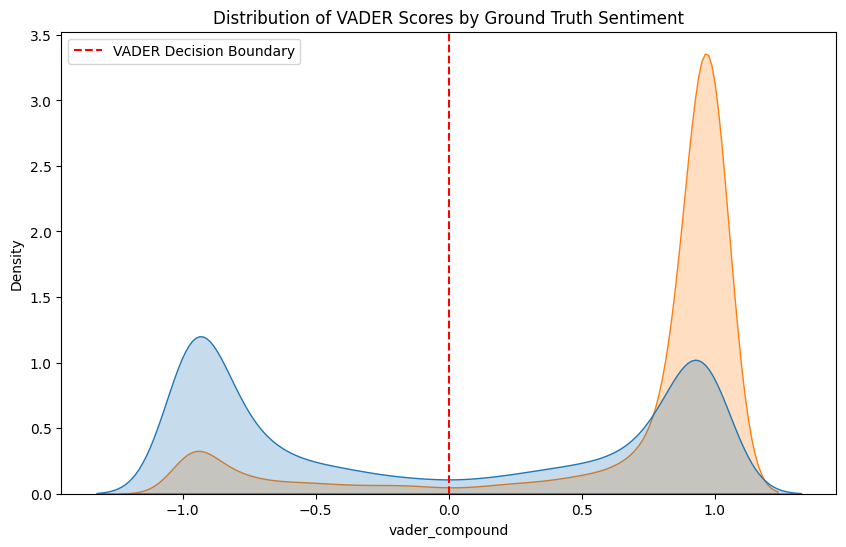

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Create a binary prediction based on VADER
# We use >= 0 as positive, < 0 as negative
df['vader_pred'] = np.where(df['vader_compound'] >= 0, 1, 0)

# 2. Basic Polarity Agreement
print("--- VADER PERFORMANCE SUMMARY ---")
accuracy = (df['vader_pred'] == df['sentiment']).mean()
print(f"Simple Polarity Accuracy: {accuracy:.2%}")

# 3. Check 'Neutral' reviews (VADER score of exactly 0)
neutrals = df[df['vader_compound'] == 0]
print(f"Number of 'Neutral' (0.0) reviews: {len(neutrals)}")
if len(neutrals) > 0:
    print(f"Neutral reviews Ground Truth: {neutrals['sentiment'].mean():.2%} are actually positive")

# 4. Detailed Metrics
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(df['sentiment'], df['vader_pred']))

# 5. ROC AUC - This measures how well VADER separates the two classes
auc = roc_auc_score(df['sentiment'], df['vader_compound'])
print(f"ROC AUC Score: {auc:.4f}")

# 6. VISUALIZATION: The Distribution Overlap
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='vader_compound', hue='sentiment', fill=True, common_norm=False)
plt.title('Distribution of VADER Scores by Ground Truth Sentiment')
plt.axvline(0, color='red', linestyle='--', label='VADER Decision Boundary')
plt.legend()
plt.show()